In [16]:
from pathlib import Path
import pandas as pd
from IPython.display import display
import util

# Load data
df = util.load_data()
display(df.head())

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort
0,2017,W,Frauen,100 m,10.95,"+1,3",Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR
1,2017,W,Frauen,100 m,11.06,"+1,8",Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda
2,2017,W,Frauen,100 m,11.14,"-0,2",Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin
3,2017,W,Frauen,100 m,11.24,"+0,3",Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL
4,2017,W,Frauen,100 m,11.25,"+1,9",Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg


In [17]:
# Choosing Disziplin / Gender 

disziplin = "5000 m"
gender = "M"
altersklasse = "Maenner"
filtered_data = df[(df["disziplin"] == disziplin) & (df["geschlecht"] == gender) & (df["altersklasse"] == altersklasse)]
filtered_data.head()


,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort
4669,2005,M,Maenner,5000 m,809.37,NaN,Jan Fitschen,1977,TV Wattenscheid 01,14.06.,Luzern/SUI
4670,2005,M,Maenner,5000 m,813.26,NaN,Arne Gabius,1981,LAV asics Tuebingen,23.07.,Heusden/BEL
4671,2005,M,Maenner,5000 m,821.41,NaN,Filmon Ghirmai,1979,LAV asics Tuebingen,18.05.,Koblenz
4672,2005,M,Maenner,5000 m,839.7,NaN,Carlo Schuff,1980,Gerolsteiner LGV,18.05.,Koblenz
4673,2005,M,Maenner,5000 m,839.74,NaN,Lars Haferkamp,1979,TV Refrath,22.06.,Papendal/NED


C:\Users\Mattis\AppData\Local\Temp\ipykernel_28400\2637383721.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data["leistung"] = filtered_data["leistung"].apply(time_to_seconds)


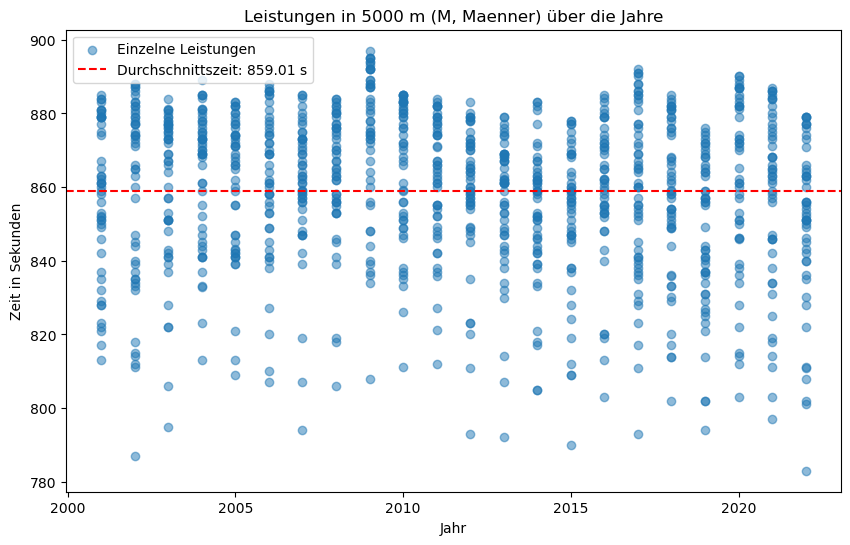

In [ ]:

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(filtered_data["jahr"], filtered_data["leistung"], alpha=0.5, label="Einzelne Leistungen")
mean_time = filtered_data["leistung"].mean()    
plt.axhline(mean_time, color='red', linestyle='--', label=f'Durchschnittszeit: {mean_time:.2f} s')
plt.title(f'Leistungen in {disziplin} ({gender}, {altersklasse}) über die Jahre')
plt.xlabel('Jahr')
plt.ylabel('Zeit in Sekunden')
plt.legend()
plt.show()

In [8]:
# Data over 1000 Seconds -> they are walking times assumably -> convert them to "5000 m Gehen"
walkers = filtered_data["leistung"] > 1400
filtered_data.loc[walkers, "disziplin"] = "5000 m Gehen"

filtered_data = filtered_data[(filtered_data["disziplin"] == disziplin) & (filtered_data["geschlecht"] == gender) & (filtered_data["altersklasse"] == altersklasse)]


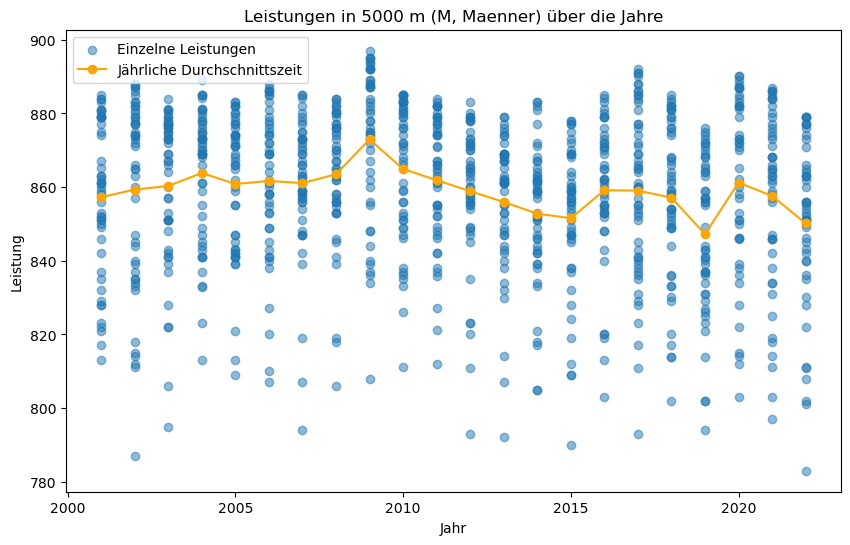

In [9]:
# Plot all data points with times on y-axis and year on x-axis + Mean per year line
mean_per_year = filtered_data.groupby("jahr")["leistung"].mean()
plt.figure(figsize=(10, 6))
plt.scatter(filtered_data["jahr"], filtered_data["leistung"], alpha=0.5, label="Einzelne Leistungen")
plt.plot(mean_per_year.index, mean_per_year.values, color='orange', marker='o', label='Jährliche Durchschnittszeit')
plt.title(f'Leistungen in {disziplin} ({gender}, {altersklasse}) über die Jahre')
plt.xlabel('Jahr')              
plt.ylabel('Leistung')
plt.legend()
plt.show()

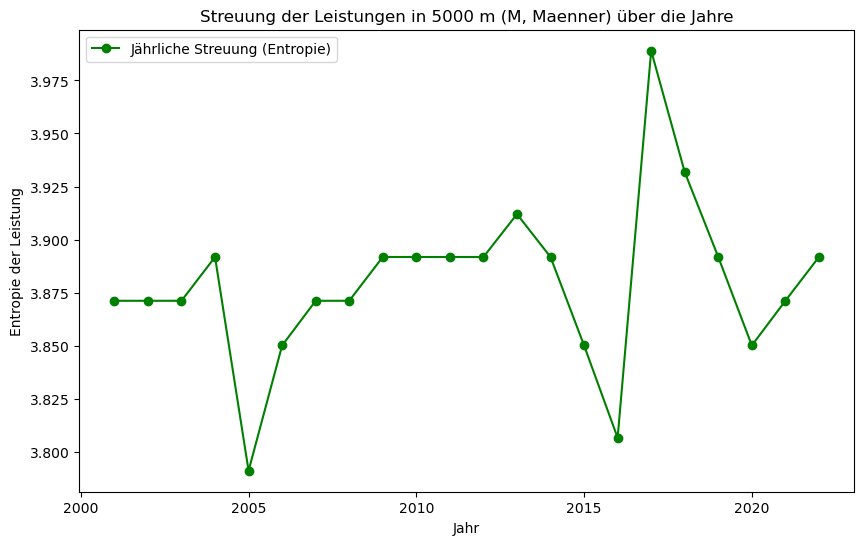

In [10]:
# What is the spread per year? -> Using Entropy

from scipy.stats import entropy
spread_per_year = filtered_data.groupby("jahr")["leistung"].apply(lambda x: entropy(x.value_counts(normalize=True)))
plt.figure(figsize=(10, 6))
plt.plot(spread_per_year.index, spread_per_year.values, color='green', marker='o', label='Jährliche Streuung (Entropie)')
plt.title(f'Streuung der Leistungen in {disziplin} ({gender}, {altersklasse}) über die Jahre')
plt.xlabel('Jahr')
plt.ylabel('Entropie der Leistung')
plt.legend()
plt.show()

C:\Users\Mattis\AppData\Local\Temp\ipykernel_28400\3349713434.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["leistung"] = subset["leistung"].apply(time_to_seconds)


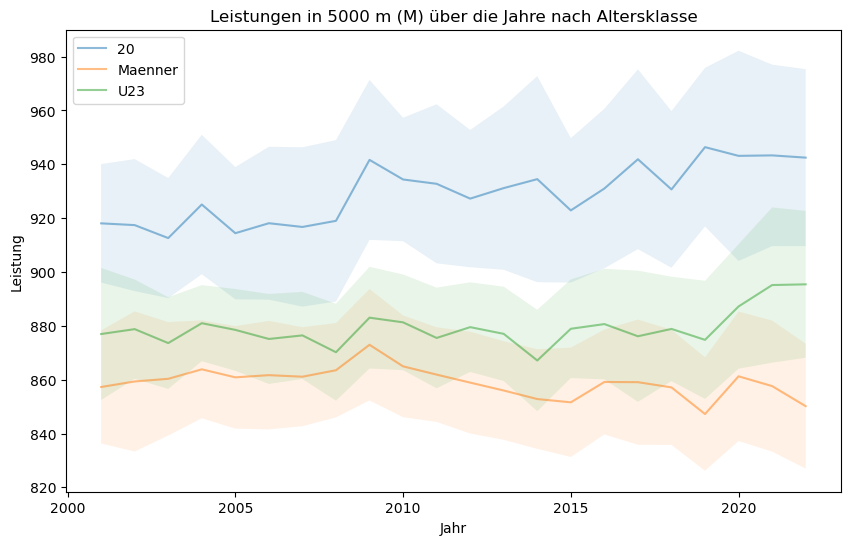

In [11]:
# Comparing different Altersklassen in the same plot; all data points
plt.figure(figsize=(10, 6))
for altersklasse in df["altersklasse"].unique():
    # If M -> exclude Frauen, W -> exclude Männer
    if gender == "M" and "Frauen" in altersklasse:
        continue
    if gender == "W" and "Maenner" in altersklasse:
        continue
    # Exclude altersklasse with too few data points
    if len(df[(df["disziplin"] == disziplin) & (df["geschlecht"] == gender) & (df["altersklasse"] == altersklasse)]) < 50:
        continue
    subset = df[(df["disziplin"] == disziplin) & (df["geschlecht"] == gender) & (df["altersklasse"] == altersklasse)]
    # Convert Leistung to seconds
    subset["leistung"] = subset["leistung"].apply(time_to_seconds)
    # Exclude walking times only on 5000m data
    if disziplin == "5000 m":
        subset = subset[subset["leistung"] <= 1400]
    # Plot means per year per altersklasse
    means = subset.groupby("jahr")["leistung"].mean()
    plt.plot(means.index, means.values, alpha=0.5, label=altersklasse)
    # Plot standard deviation per year per altersklasse
    stds = subset.groupby("jahr")["leistung"].std()
    plt.fill_between(stds.index, means - stds, means + stds, alpha=0.1)
plt.title(f'Leistungen in {disziplin} ({gender}) über die Jahre nach Altersklasse')
plt.xlabel('Jahr')
plt.ylabel('Leistung')
plt.legend()
plt.show()

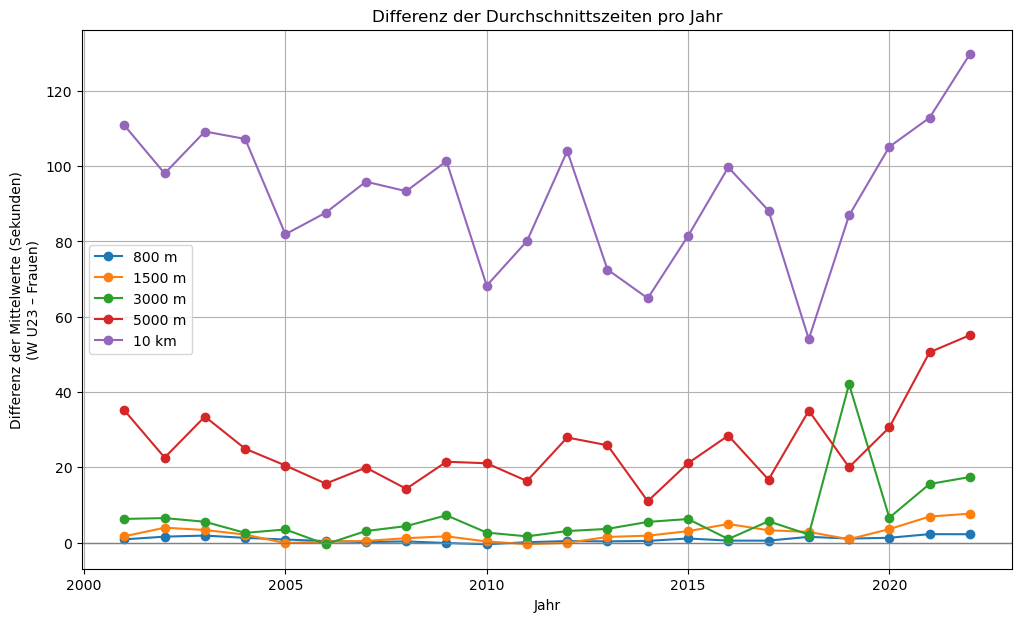

In [12]:
plt.figure(figsize=(12, 7))

disziplinen = ["800 m","1500 m", "3000 m", "5000 m", "10 km"]

for disziplin in disziplinen:
    # Mittelwerte speichern
    means = {}

    for altersklasse in ["U23", "Frauen"]:
        subset = df[
            (df["disziplin"] == disziplin) &
            (df["geschlecht"] == "W") &
            (df["altersklasse"] == altersklasse)
        ].copy()
        # Zeit → Sekunden
        subset.loc[:, "leistung"] = subset["leistung"].apply(time_to_seconds)

        # Outlier-Filter nur bei 5000 m
        if disziplin == "5000 m":
            subset = subset[subset["leistung"] <= 1400]
        if disziplin == "10 km":
            subset = subset[subset["leistung"] >= 500]
        if disziplin == "1500 m":
                subset = subset[subset["leistung"] <= 400]
        # Mittelwert pro Jahr
        means[altersklasse] = subset.groupby("jahr")["leistung"].mean()
    # gemeinsame Jahre
    common_years = means["U23"].index.intersection(means["Frauen"].index)
    # einfache Differenz der Mittelwerte
    difference = means["U23"].loc[common_years] - means["Frauen"].loc[common_years]
    
    # Plotten
    plt.plot(
        difference.index,
        difference.values,
        marker="o",
        label=disziplin
    )

plt.axhline(0, color="gray", linewidth=1)  # Hilfslinie
plt.xlabel("Jahr")
plt.ylabel("Differenz der Mittelwerte (Sekunden)\n(W U23 – Frauen)")
plt.title("Differenz der Durchschnittszeiten pro Jahr")
plt.legend()
plt.grid(True)
plt.show()


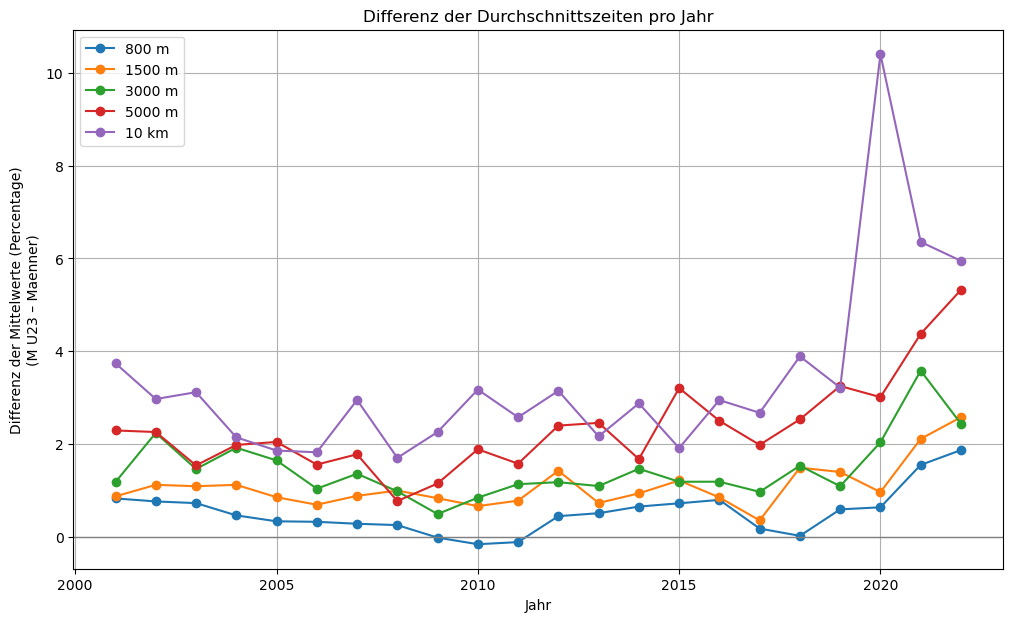

In [13]:
plt.figure(figsize=(12, 7))

# Seconds does not allow for comparison between distances, its clear there is more difference in longer races7
# Changing to percentage difference

disziplinen = ["800 m","1500 m", "3000 m", "5000 m", "10 km"]

for disziplin in disziplinen:
    # Mittelwerte speichern
    means = {}

    for altersklasse in ["U23", "Maenner"]:
        subset = df[
            (df["disziplin"] == disziplin) &
            (df["geschlecht"] == "M") &
            (df["altersklasse"] == altersklasse)
        ].copy()
        # Zeit → Sekunden
        subset.loc[:, "leistung"] = subset["leistung"].apply(time_to_seconds)

        # Outlier-Filter nur bei 5000 m
        if disziplin == "5000 m":
            subset = subset[subset["leistung"] <= 1400]
        if disziplin == "10 km":
            subset = subset[subset["leistung"] >= 500]
        if disziplin == "1500 m":
            subset = subset[subset["leistung"] <= 400]
        # Mittelwert pro Jahr
        means[altersklasse] = subset.groupby("jahr")["leistung"].mean()
    # gemeinsame Jahre
    common_years = means["U23"].index.intersection(means["Maenner"].index)
    # einfache Differenz der Mittelwerte
    difference = (means["U23"].loc[common_years] - means["Maenner"].loc[common_years]) \
                / means["Maenner"].loc[common_years] * 100
    
    # Plotten
    plt.plot(
        difference.index,
        difference.values,
        marker="o",
        label=disziplin
    )

plt.axhline(0, color="gray", linewidth=1)  # Hilfslinie
plt.xlabel("Jahr")
plt.ylabel("Differenz der Mittelwerte (Percentage)\n(M U23 – Maenner)")
plt.title("Differenz der Durchschnittszeiten pro Jahr")
plt.legend()
plt.grid(True)
plt.show()


In [14]:
# Mean Difference for M U23 and Maenner and W U23 and Frauen summed over all years for every disziplin
disziplinen = ["800 m","1500 m", "3000 m", "5000 m", "10 km"]
gender = ["W", "M"]
for gender in gender:
    if gender == "W":
        ak = "Frauen"
    else:
        ak = "Maenner"
    print(ak)
    for disziplin in disziplinen:
        # Mittelwerte speichern
        means = {}
        for altersklasse in ["U23", ak]:
            subset = df[
                (df["disziplin"] == disziplin) &
                (df["geschlecht"] == gender) &
                (df["altersklasse"] == altersklasse)
            ].copy()
            # Zeit → Sekunden
            subset.loc[:, "leistung"] = subset["leistung"].apply(time_to_seconds)

            # Outlier-Filter nur bei 5000 m
            if disziplin == "5000 m":
                subset = subset[subset["leistung"] <= 1400]
            if disziplin == "10 km":
                subset = subset[subset["leistung"] >= 500]
            if disziplin == "1500 m":
                subset = subset[subset["leistung"] <= 400]
            # Mittelwert pro Jahr
            means[altersklasse] = subset.groupby("jahr")["leistung"].mean()
        # gemeinsame Jahre
        common_years = means["U23"].index.intersection(means[ak].index)
        common_years = common_years[common_years != 2020]
        # einfache Differenz der Mittelwerte
        difference = (means["U23"].loc[common_years] - means[ak].loc[common_years]) \
                    / means[ak].loc[common_years] * 100
        avg_difference = difference.mean()
        print(f"Average difference in {disziplin} for {gender} and U23: {avg_difference:.2f}%")


Frauen
Average difference in 800 m for W and U23: 0.63%
Average difference in 1500 m for W and U23: 0.85%
Average difference in 3000 m for W and U23: 1.21%
Average difference in 5000 m for W and U23: 2.54%
Average difference in 10 km for W and U23: 4.37%
Maenner
Average difference in 800 m for M and U23: 0.53%
Average difference in 1500 m for M and U23: 1.10%
Average difference in 3000 m for M and U23: 1.43%
Average difference in 5000 m for M and U23: 2.31%
Average difference in 10 km for M and U23: 3.02%


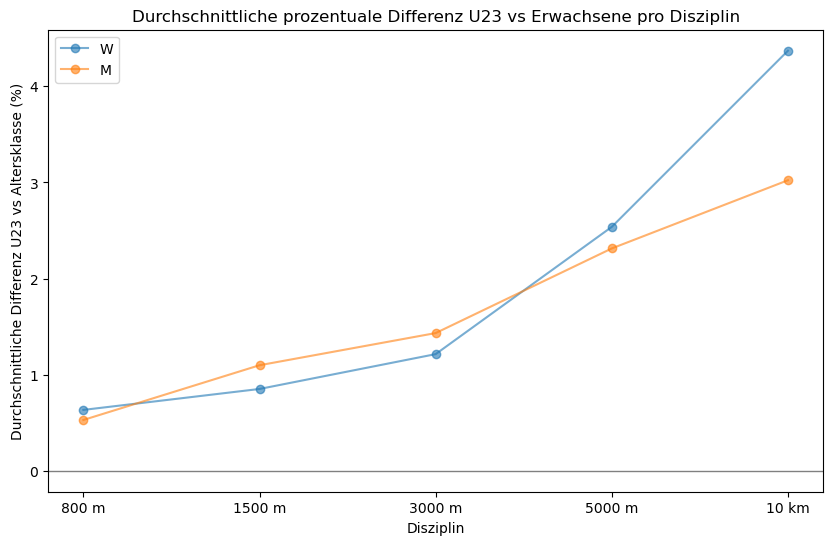

In [15]:
import matplotlib.pyplot as plt

disziplinen = ["800 m","1500 m", "3000 m", "5000 m", "10 km"]
genders = ["W", "M"]

# Ergebnisse speichern
results = {"Disziplin": [], "Gender": [], "AvgDiffPercent": []}

for gender in genders:
    ak = "Frauen" if gender == "W" else "Maenner"
    
    for disziplin in disziplinen:
        means = {}
        for altersklasse in ["U23", ak]:
            subset = df[
                (df["disziplin"] == disziplin) &
                (df["geschlecht"] == gender) &
                (df["altersklasse"] == altersklasse)
            ].copy()
            subset.loc[:, "leistung"] = subset["leistung"].apply(time_to_seconds)

            # Outlier-Filter
            if disziplin == "5000 m":
                subset = subset[subset["leistung"] <= 1400]
            if disziplin == "10 km":
                subset = subset[subset["leistung"] >= 500]
            if disziplin == "1500 m":
                subset = subset[subset["leistung"] <= 400]

            means[altersklasse] = subset.groupby("jahr")["leistung"].mean()
        
        # Gemeinsame Jahre, 2020 ausschließen
        common_years = means["U23"].index.intersection(means[ak].index)
        common_years = common_years[common_years != 2020]
        
        # Prozentdifferenz berechnen
        difference = (means["U23"].loc[common_years] - means[ak].loc[common_years]) \
                     / means[ak].loc[common_years] * 100
        avg_difference = difference.mean()
        
        # Ergebnisse speichern
        results["Disziplin"].append(disziplin)
        results["Gender"].append(gender)
        results["AvgDiffPercent"].append(avg_difference)

# Plot
fig, ax = plt.subplots(figsize=(10,6))

for gender in genders:
    mask = [g == gender for g in results["Gender"]]
    x = [d for d, m in zip(results["Disziplin"], mask) if m]
    y = [v for v, m in zip(results["AvgDiffPercent"], mask) if m]
    ax.plot(x, y, marker="o", alpha=0.6, label=gender)

ax.set_xlabel("Disziplin")
ax.set_ylabel("Durchschnittliche Differenz U23 vs Altersklasse (%)")
ax.set_title("Durchschnittliche prozentuale Differenz U23 vs Erwachsene pro Disziplin")
ax.axhline(0, color="gray", linewidth=1)
ax.legend(["W", "M"])
plt.show()
